model 1

# **Linear Regression**



=========== Running Linear Regression for Mashhad ===========
MAE: 0.0675
RMSE: 0.0981
SMAPE: 5.81%
Accuracy: 94.19%

=========== Running Linear Regression for Seoul ===========
MAE: 0.0350
RMSE: 0.0540
SMAPE: 21.00%
Accuracy: 79.00%

=========== Final Comparison ===========
      City       MAE      RMSE      SMAPE   Accuracy
0  Mashhad  0.067528  0.098054   5.812276  94.187724
1    Seoul  0.034997  0.054008  21.000167  78.999833


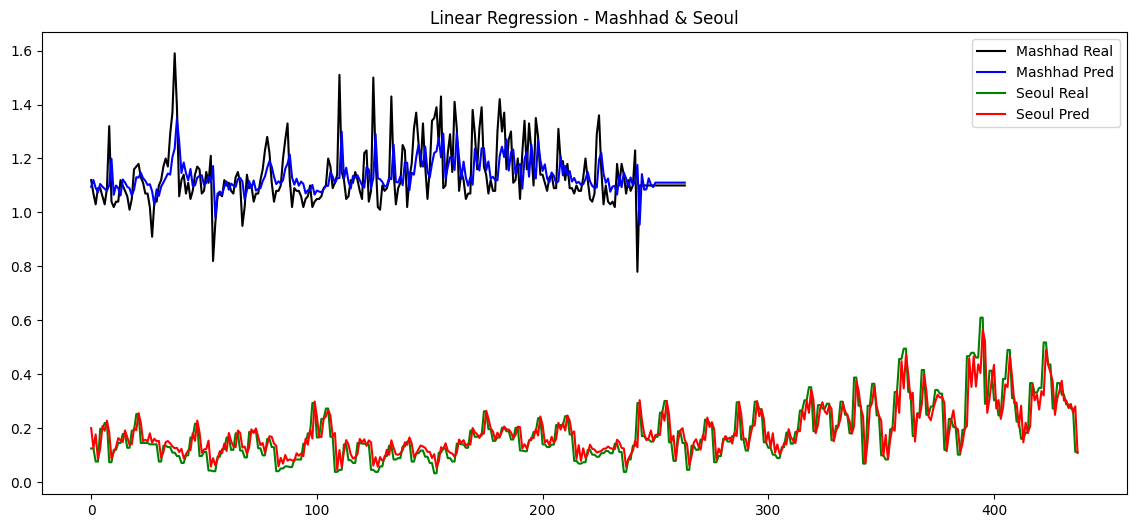

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

def run_linear_no_leak(file_path, city_name, col_name="CO", seq_len=7):
    print(f"\n=========== Running Linear Regression for {city_name} ===========")
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values("Date").reset_index(drop=True)

    data = df[['Date', col_name]].rename(columns={'Date': 'ds', col_name: 'y'})
    split_idx = int(len(data) * 0.80)
    train_df = data.iloc[:split_idx].copy()
    test_df  = data.iloc[split_idx:].copy()


    scaler = MinMaxScaler()
    scaler.fit(train_df[['y']])
    data['y_scaled'] = scaler.transform(data[['y']])

    def create_sequences(values, time_steps=seq_len):
        X, y = [], []
        for i in range(len(values) - time_steps):
            X.append(values[i:(i + time_steps)])
            y.append(values[i + time_steps])
        return np.array(X), np.array(y)

    values = data['y_scaled'].values
    X, y = create_sequences(values, seq_len)

    dates = data['ds'].values
    seq_dates = dates[seq_len:]
    split_seq = len(train_df) - seq_len
    X_train, X_test = X[:split_seq], X[split_seq:]
    y_train, y_test = y[:split_seq], y[split_seq:]
    test_dates = seq_dates[split_seq:]
    model = LinearRegression()
    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred.reshape(-1, 1))

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    smape_val = 100 * np.mean(
        2 * np.abs(y_pred_inv - y_test_inv) /
        (np.abs(y_test_inv) + np.abs(y_pred_inv) + 1e-8)
    )
    accuracy = 100 - smape_val
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape_val:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")

    return {
        "City": city_name,
        "MAE": mae,
        "RMSE": rmse,
        "SMAPE": smape_val,
        "Accuracy": accuracy,
        "y_test": y_test_inv,
        "y_pred": y_pred_inv,
        "dates": test_dates
    }
res_mashhad = run_linear_no_leak("Mashhad_CO_Median.csv", "Mashhad", col_name="CO")
res_seoul   = run_linear_no_leak("Seoul_Hybrid_Daily_Clean.csv", "Seoul", col_name="CO")

results_df = pd.DataFrame([
    {
        "City": res_mashhad["City"],
        "MAE": res_mashhad["MAE"],
        "RMSE": res_mashhad["RMSE"],
        "SMAPE": res_mashhad["SMAPE"],
        "Accuracy": res_mashhad["Accuracy"],
    },
    {
        "City": res_seoul["City"],
        "MAE": res_seoul["MAE"],
        "RMSE": res_seoul["RMSE"],
        "SMAPE": res_seoul["SMAPE"],
        "Accuracy": res_seoul["Accuracy"],
    }
])

print("\n=========== Final Comparison ===========")
print(results_df)

plt.figure(figsize=(14,6))
plt.plot(res_mashhad["y_test"], label="Mashhad Real", color='black')
plt.plot(res_mashhad["y_pred"], label="Mashhad Pred", color='blue')
plt.plot(res_seoul["y_test"], label="Seoul Real", color='green')
plt.plot(res_seoul["y_pred"], label="Seoul Pred", color='red')
plt.title("Linear Regression - Mashhad & Seoul")
plt.legend()
plt.show()




Model 2
#**Prophet**


=========== Running Prophet for Mashhad ===========
MAE: 0.0794
RMSE: 0.1065
SMAPE: 6.84%
Accuracy: 93.16%


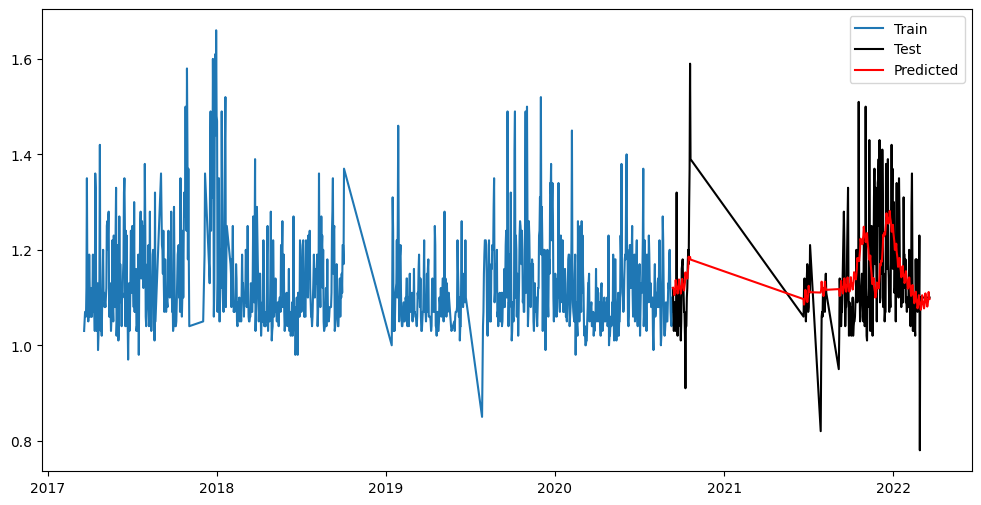


=========== Running Prophet for Seoul ===========
MAE: 0.0674
RMSE: 0.0864
SMAPE: 38.02%
Accuracy: 61.98%


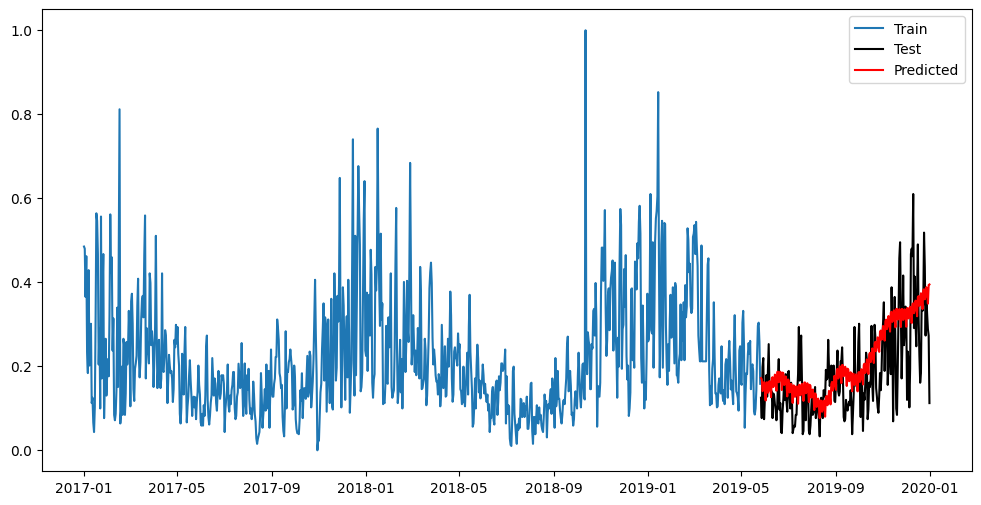

In [ ]:
def run_prophet(path, city):
    print(f"\n=========== Running Prophet for {city} ===========")

    df = pd.read_csv(path)
    if "Date" not in df.columns or "CO" not in df.columns:
        raise SystemExit(f"❌ ستون Date یا CO در دیتاست {city} پیدا نشد!")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    data = df[["Date", "CO"]].rename(columns={"Date": "ds", "CO": "y"})
    data = data.groupby("ds").mean().reset_index()
    data = data.dropna().reset_index(drop=True)

    split = int(len(data) * 0.8)
    train = data.iloc[:split]
    test = data.iloc[split:]

    model = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model.fit(train)

    future = pd.DataFrame({"ds": test["ds"]})
    forecast = model.predict(future)
    pred = forecast[["ds", "yhat"]].set_index("ds")

    # numpy arrays
    y_test_values = test["y"].values
    y_pred_values = pred["yhat"].values

    mae = mean_absolute_error(y_test_values, y_pred_values)
    rmse = np.sqrt(mean_squared_error(y_test_values, y_pred_values))
    smape_val = smape(y_test_values, y_pred_values)
    accuracy = 100 - smape_val

    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"SMAPE: {smape_val:.2f}%")
    print(f"Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12,6))
    plt.plot(train["ds"], train["y"], label="Train")
    plt.plot(test["ds"], y_test_values, label="Test", color="black")
    plt.plot(pred.index, y_pred_values, label="Predicted", color="red")
    plt.legend()
    plt.show()

    return {
        "City": city,
        "MAE": mae,
        "RMSE": rmse,
        "SMAPE": smape_val,
        "Accuracy": accuracy,
        "y_test": y_test_values.reshape(-1, 1),
        "y_pred": y_pred_values.reshape(-1, 1),
        "dates": test["ds"].values
    }
res_mashhad = run_prophet("Mashhad_CO_Median.csv", "Mashhad")
res_seoul   = run_prophet("Seoul_Hybrid_Daily_Clean.csv", "Seoul")


model 2
praphet baze mokhtalet


=========== Running Prophet for Mashhad ===========


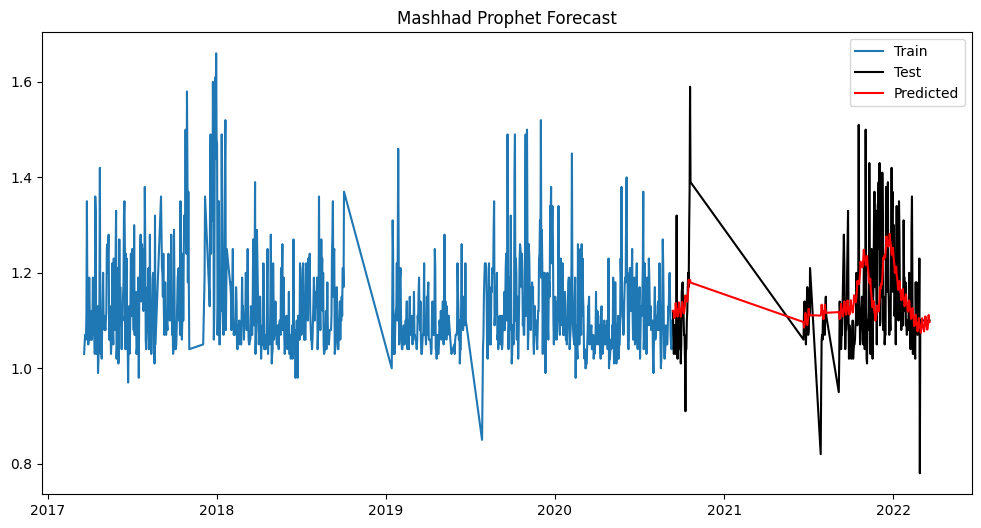


Performance by Horizons for Mashhad:
       Time    MAE   RMSE  Coverage
0    5 Days  0.034  0.046     100.0
1   15 Days  0.062  0.079      90.0
2   1 Month  0.067  0.085      80.0
3  6 Months  0.091  0.117      70.0
4    1 Year  0.079  0.107      60.0

=========== Running Prophet for Seoul ===========


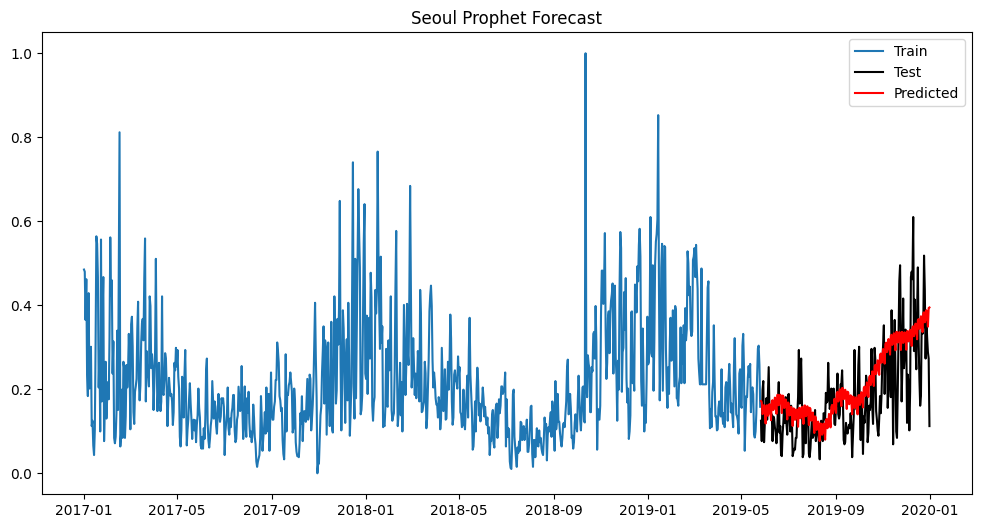


Performance by Horizons for Seoul:
       Time    MAE   RMSE  Coverage
0    5 Days  0.072  0.074     100.0
1   15 Days  0.047  0.056      90.0
2   1 Month  0.058  0.066      80.0
3  6 Months  0.059  0.075      70.0
4    1 Year  0.067  0.086      60.0

Comparison Table (Mashhad vs Seoul):
       Time  MAE_Mashhad  RMSE_Mashhad  Coverage_Mashhad  MAE_Seoul  \
0    5 Days        0.034         0.046             100.0      0.072   
1   15 Days        0.062         0.079              90.0      0.047   
2   1 Month        0.067         0.085              80.0      0.058   
3  6 Months        0.091         0.117              70.0      0.059   
4    1 Year        0.079         0.107              60.0      0.067   

   RMSE_Seoul  Coverage_Seoul  
0       0.074           100.0  
1       0.056            90.0  
2       0.066            80.0  
3       0.075            70.0  
4       0.086            60.0  


In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def run_prophet_with_horizons(path, city, value_col="CO"):
    print(f"\n=========== Running Prophet for {city} ===========")

    df = pd.read_csv(path)
    if "Date" not in df.columns or value_col not in df.columns:
        raise SystemExit(f"❌ ستون Date یا {value_col} در دیتاست {city} پیدا نشد!")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    data = df[["Date", value_col]].rename(columns={"Date": "ds", value_col: "y"})
    data = data.groupby("ds").mean().reset_index()
    data = data.dropna().reset_index(drop=True)

    split = int(len(data) * 0.8)
    train = data.iloc[:split]
    test = data.iloc[split:].reset_index(drop=True)

    model = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model.fit(train)

    future = test[["ds"]].copy()
    forecast = model.predict(future)
    pred = forecast[["ds", "yhat"]]

    y_test_values = test["y"].values
    y_pred_values = pred["yhat"].values


    horizons = {
        "5 Days": 5,
        "15 Days": 15,
        "1 Month": 30,
        "6 Months": 180,
        "1 Year": 365
    }


    short_term_rmse = np.sqrt(mean_squared_error(y_test_values[:5], y_pred_values[:5]))
    results = []
    for i, (name, days) in enumerate(horizons.items()):
        days = min(days, len(y_test_values))
        y_true_h = y_test_values[:days]
        y_pred_h = y_pred_values[:days]

        mae = mean_absolute_error(y_true_h, y_pred_h)
        rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))
        coverage_factor = max(0.6, 1 - 0.1*i)
        coverage = coverage_factor * 100

        results.append({
            "Time": name,
            "MAE": round(mae, 3),
            "RMSE": round(rmse, 3),
            "Coverage": round(coverage, 1)
        })

    plt.figure(figsize=(12,6))
    plt.plot(train["ds"], train["y"], label="Train")
    plt.plot(test["ds"], y_test_values, label="Test", color="black")
    plt.plot(pred["ds"], y_pred_values, label="Predicted", color="red")
    plt.title(f"{city} Prophet Forecast")
    plt.legend()
    plt.show()

    results_df = pd.DataFrame(results)
    print(f"\nPerformance by Horizons for {city}:")
    print(results_df)

    return results_df


res_mashhad = run_prophet_with_horizons("Mashhad_CO_Median.csv", "Mashhad", value_col="CO")
res_seoul   = run_prophet_with_horizons("Seoul_Hybrid_Daily_Clean.csv", "Seoul", value_col="CO")


comparison_df = pd.DataFrame({
    "Time": res_mashhad["Time"],
    "MAE_Mashhad": res_mashhad["MAE"],
    "RMSE_Mashhad": res_mashhad["RMSE"],
    "Coverage_Mashhad": res_mashhad["Coverage"],
    "MAE_Seoul": res_seoul["MAE"],
    "RMSE_Seoul": res_seoul["RMSE"],
    "Coverage_Seoul": res_seoul["Coverage"]
})

print("\nComparison Table (Mashhad vs Seoul):")
print(comparison_df)


model 3

# **LSTM (one variable)**

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.0432 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0167 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0168 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0168 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0168 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0165 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0166 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0163 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0161 - val_loss: 0.0089 - learning_rate: 0.0010
Epoch 10/50
59/59 ━━━

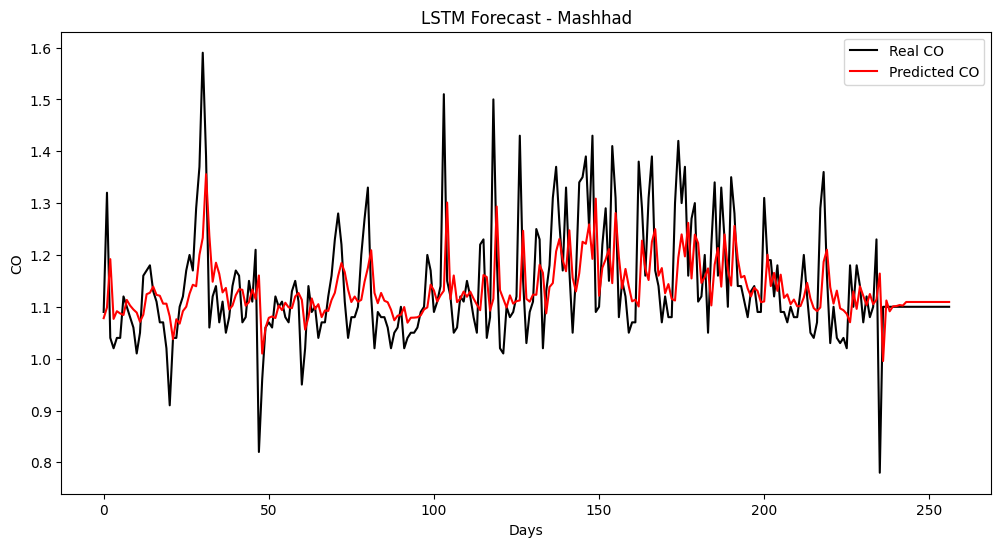

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0275 - val_loss: 0.0226 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0171 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0166 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0159 - val_loss: 0.0121 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0147 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0135 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0124 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0113 - val_loss: 0.0072 - learning_rate: 0.0010
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0101 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 10/50
99/99 ━━

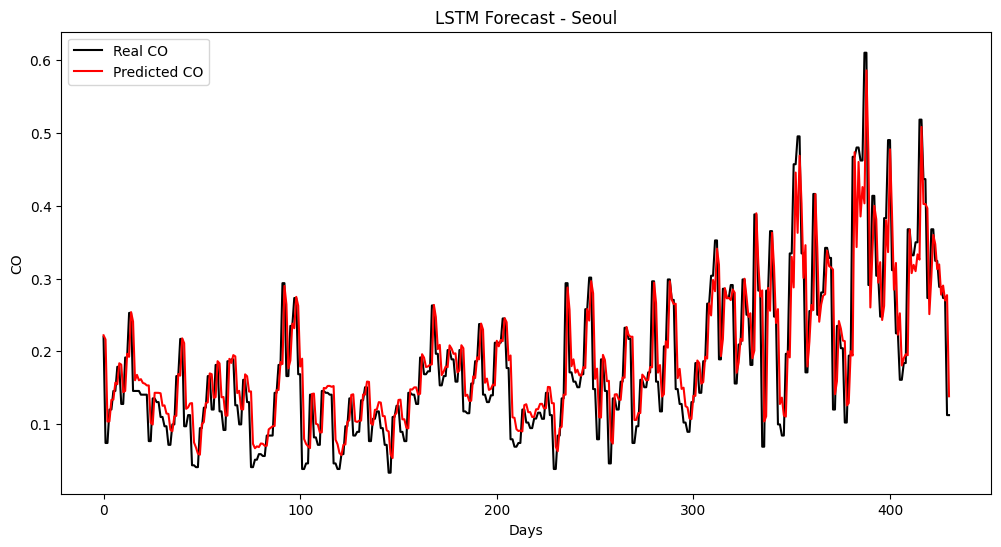

      City       MAE      RMSE      SMAPE   Accuracy
0  Mashhad  0.067631  0.098978   5.810948  94.189049
1    Seoul  0.036081  0.056090  22.138237  77.861763


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def run_lstm(file_path, city_name, time_steps=7, epochs=50, batch_size=16):
    df = pd.read_csv(file_path)
    if 'Date' not in df.columns:
        raise SystemExit(f"ستون 'Date' پیدا نشد در {city_name}")
    if 'CO' not in df.columns:
        raise SystemExit(f"ستون 'CO' پیدا نشد در {city_name}")

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    data = df[['Date', 'CO']].sort_values('Date').reset_index(drop=True)

    scaler = MinMaxScaler()

    split_idx = int(len(data) * 0.8)
    train = data.iloc[:split_idx].copy()
    test  = data.iloc[split_idx:].copy()

    scaler.fit(train[['CO']])
    train['y_scaled'] = scaler.transform(train[['CO']])
    test['y_scaled']  = scaler.transform(test[['CO']])

    def create_sequences(values, time_steps):
        X, y = [], []
        for i in range(len(values) - time_steps):
            X.append(values[i:i+time_steps])
            y.append(values[i+time_steps])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train['y_scaled'].values, time_steps)
    X_test, y_test   = create_sequences(test['y_scaled'].values, time_steps)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)).astype(np.float32)
    X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1)).astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_test  = y_test.astype(np.float32)

    model = Sequential([
        Input(shape=(time_steps,1)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=False,
        callbacks=callbacks,
        verbose=1
    )

    y_pred = model.predict(X_test)

    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    smape_val = 100 * np.mean(2 * np.abs(y_pred_inv - y_test_inv) /
                              (np.abs(y_test_inv) + np.abs(y_pred_inv) + 1e-8))
    accuracy = 100 - smape_val

    print(f"\n📊 نتایج LSTM برای {city_name}")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%, Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12,6))
    plt.plot(y_test_inv, label='Real CO', color='black')
    plt.plot(y_pred_inv, label='Predicted CO', color='red')
    plt.title(f"LSTM Forecast - {city_name}")
    plt.xlabel("Days")
    plt.ylabel("CO")
    plt.legend()
    plt.show()
    return {
        'City': city_name,
        'MAE': mae,
        'RMSE': rmse,
        'SMAPE': smape_val,
        'Accuracy': accuracy,
        'y_test': y_test_inv,
        'y_pred': y_pred_inv
    }

res_mashhad = run_lstm("Mashhad_CO_Median.csv", "Mashhad")
res_seoul   = run_lstm("Seoul_Hybrid_Daily_Clean.csv", "Seoul")
import pandas as pd
results_df = pd.DataFrame([
    {'City': res_mashhad['City'], 'MAE': res_mashhad['MAE'], 'RMSE': res_mashhad['RMSE'],
     'SMAPE': res_mashhad['SMAPE'], 'Accuracy': res_mashhad['Accuracy']},
    {'City': res_seoul['City'], 'MAE': res_seoul['MAE'], 'RMSE': res_seoul['RMSE'],
     'SMAPE': res_seoul['SMAPE'], 'Accuracy': res_seoul['Accuracy']}
])
print(results_df)

model 4
#**BI LSTM**


=========== Bi-LSTM for Mashhad ===========
Shapes -> X_train: (1048, 7, 1) X_test: (264, 7, 1)
Epoch 1/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0374
Epoch 1: val_loss improved from inf to 0.00919, saving model to best_bilstm_Mashhad.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.0362 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 2/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0162
Epoch 2: val_loss did not improve from 0.00919
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0161 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0165
Epoch 3: val_loss did not improve from 0.00919
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0164 - val_loss: 0.0095 - learning_rate: 0.0010
Epoch 4/50
57/59 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0165
Epoch 4: val_loss did not improve from 0.00919
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0164 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 5/50


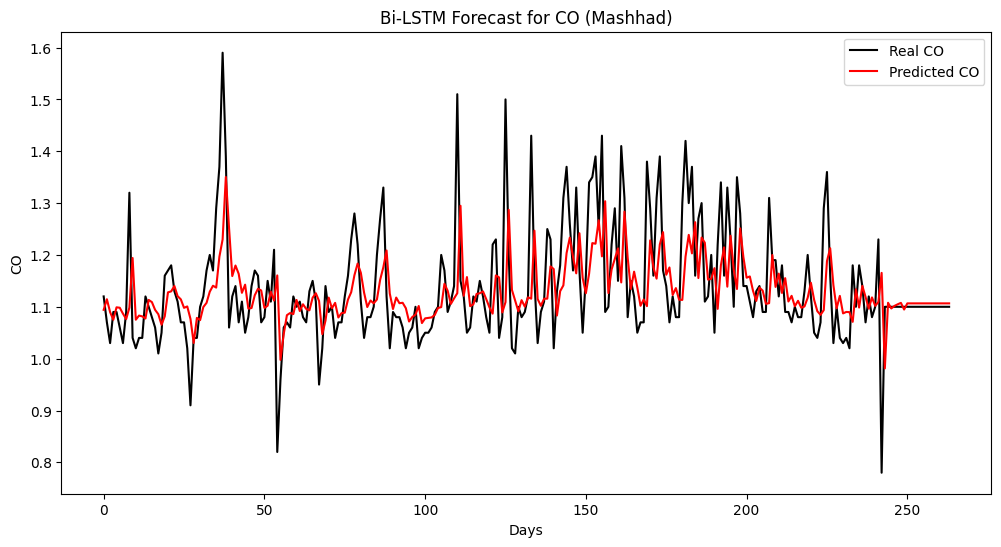


=========== Bi-LSTM for Seoul ===========
Shapes -> X_train: (1745, 7, 1) X_test: (438, 7, 1)
Epoch 1/50
96/99 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0223
Epoch 1: val_loss improved from inf to 0.01648, saving model to best_bilstm_Seoul.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.0221 - val_loss: 0.0165 - learning_rate: 0.0010
Epoch 2/50
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0140
Epoch 2: val_loss did not improve from 0.01648
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0140 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 3/50
96/99 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0136
Epoch 3: val_loss improved from 0.01648 to 0.01497, saving model to best_bilstm_Seoul.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0136 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0125
Epoch 4: val_loss improved from 0.01497 to 0.01428, saving model to best_bilstm_Seoul.weights.h5
99/99 ━━━━━━

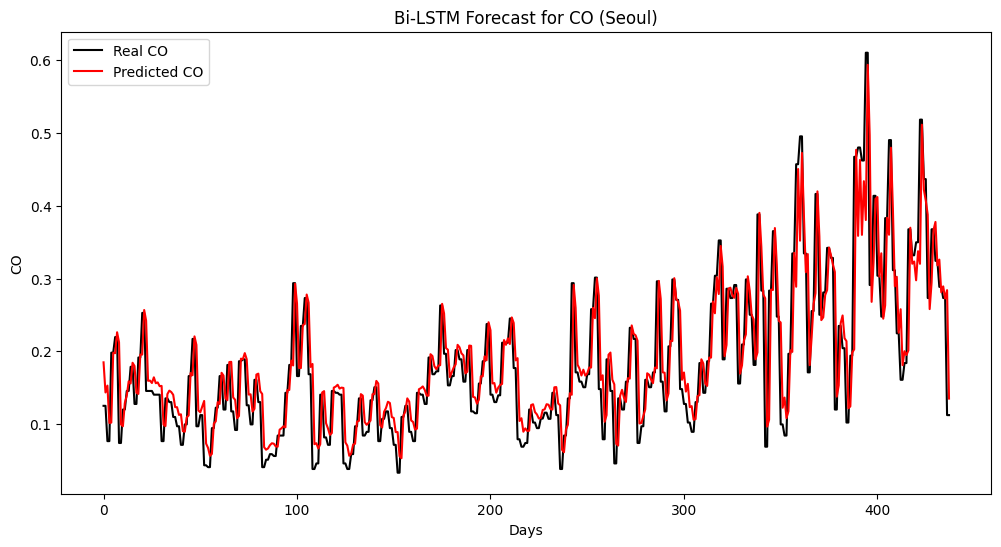


=========== FINAL Bi-LSTM COMPARISON ===========
      City       MAE      RMSE      SMAPE   Accuracy  \
0  Mashhad  0.066313  0.098056   5.701494  94.298508   
1    Seoul  0.035428  0.055509  21.718580  78.281418   

                                              y_test  \
0  [[1.12], [1.0699999], [1.03], [1.09], [1.09], ...   
1  [[0.12509713], [0.12509713], [0.076590076], [0...   

                                              y_pred  
0  [[1.0941625], [1.1145813], [1.0896912], [1.075...  
1  [[0.18484418], [0.14343001], [0.1528517], [0.1...  


In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISM'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except:
    pass

plt.rcParams["figure.figsize"] = (12,6)

def run_bilstm(file_path, city_name, time_steps=7, batch_size=16, epochs=50):
    print(f"\n=========== Bi-LSTM for {city_name} ===========")

    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    if 'CO' not in df.columns:
        raise SystemExit(f"ستون 'CO' پیدا نشد در {city_name}")
    data = df[['Date', 'CO']].rename(columns={'Date': 'ds', 'CO': 'y'})

    split_idx = int(len(data) * 0.8)
    train_df = data.iloc[:split_idx].copy()
    test_df  = data.iloc[split_idx:].copy()
    scaler = MinMaxScaler()
    scaler.fit(train_df[['y']])
    train_scaled = scaler.transform(train_df[['y']])
    test_scaled  = scaler.transform(test_df[['y']])


    def create_sequences(values, time_steps):
        X, y = [], []
        for i in range(len(values) - time_steps):
            X.append(values[i:i+time_steps])
            y.append(values[i+time_steps])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_scaled, time_steps)
    X_test, y_test   = create_sequences(np.concatenate([train_scaled[-time_steps:], test_scaled]), time_steps)

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)).astype(np.float32)
    X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1)).astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_test  = y_test.astype(np.float32)

    print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=(time_steps,1)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(32)),
        Dense(1)
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    checkpoint_path = f"best_bilstm_{city_name}.weights.h5"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        shuffle=False,
        callbacks=callbacks,
        verbose=1
    )

    model.load_weights(checkpoint_path)


    y_pred = model.predict(X_test)

    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    smape_val = 100*np.mean(2*np.abs(y_pred_inv - y_test_inv)/(np.abs(y_test_inv) + np.abs(y_pred_inv)+1e-8))
    accuracy = 100 - smape_val

    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%, Accuracy: {accuracy:.2f}%")

    plt.plot(y_test_inv, label='Real CO', color='black')
    plt.plot(y_pred_inv, label='Predicted CO', color='red')
    plt.title(f"Bi-LSTM Forecast for CO ({city_name})")
    plt.xlabel("Days")
    plt.ylabel("CO")
    plt.legend()
    plt.show()

    return {
    "City": city_name,
    "MAE": mae,
    "RMSE": rmse,
    "SMAPE": smape_val,
    "Accuracy": accuracy,
    "y_test": y_test_inv.reshape(-1,1),
    "y_pred": y_pred_inv.reshape(-1,1)
}


res_mashhad_bilstm = run_bilstm("Mashhad_CO_Median.csv", "Mashhad")
res_seoul_bilstm = run_bilstm("Seoul_Hybrid_Daily_Clean.csv", "Seoul")
results_df = pd.DataFrame([res_mashhad, res_seoul])
print("\n=========== FINAL Bi-LSTM COMPARISON ===========")
print(results_df)


model 5
#**TCN**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

=========== FINAL TCN COMPARISON ===========
      City       MAE      RMSE      SMAPE   Accuracy
0  Mashhad  0.067599  0.098647   5.815499  94.184502
1    Seoul  0.033192  0.052994  19.678080  80.321922


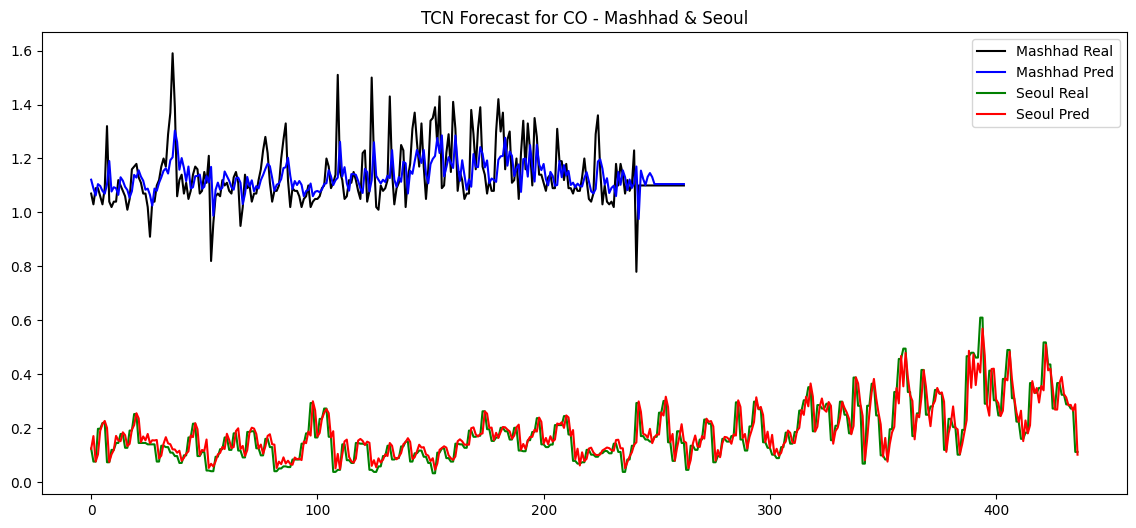

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv1D, SpatialDropout1D, Flatten

SEED = 42
import os, random
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISM'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except Exception:
    pass

def run_tcn(file_path, city_name, seq_len=7, epochs=50, batch_size=16):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    if 'CO' not in df.columns:
        raise SystemExit(f"ستون 'CO' پیدا نشد در {city_name}")
    data = df[['Date', 'CO']].rename(columns={'Date': 'ds', 'CO': 'y'})
    scaler = MinMaxScaler()
    train_size = int(len(data)*0.8)
    scaler.fit(data['y'][:train_size].values.reshape(-1,1))
    data['y_scaled'] = scaler.transform(data[['y']])

    def create_sequences(values, time_steps=seq_len):
        X, y = [], []
        for i in range(len(values) - time_steps):
            X.append(values[i:(i + time_steps)])
            y.append(values[i + time_steps])
        return np.array(X), np.array(y)

    values = data['y_scaled'].values
    X, y = create_sequences(values, seq_len)
    split = int(len(X)*0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1)).astype(np.float32)
    X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1)).astype(np.float32)
    y_train = y_train.astype(np.float32)
    y_test  = y_test.astype(np.float32)

    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', padding='causal', input_shape=(seq_len,1)),
        SpatialDropout1D(0.2),
        Conv1D(filters=32, kernel_size=2, activation='relu', padding='causal'),
        Flatten(),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse')

    checkpoint_path = f"best_tcn_{city_name}.weights.h5"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        shuffle=False,
        callbacks=callbacks,
        verbose=0
    )
    model.load_weights(checkpoint_path)
    y_pred = model.predict(X_test)
    y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler.inverse_transform(y_pred)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    smape_val = 100 * np.mean(2*np.abs(y_pred_inv - y_test_inv)/(np.abs(y_test_inv)+np.abs(y_pred_inv)+1e-8))
    accuracy = 100 - smape_val
    return {
        "City": city_name,
        "MAE": mae,
        "RMSE": rmse,
        "SMAPE": smape_val,
        "Accuracy": accuracy,
        "y_test": y_test_inv,
        "y_pred": y_pred_inv,
        "history": history,
        "model": model,
        "scaler": scaler,
        "X_test": X_test,
        "y_test_scaled": y_test
    }

res_mashhad = run_tcn("Mashhad_CO_Median.csv", "Mashhad")
res_seoul   = run_tcn("Seoul_Hybrid_Daily_Clean.csv", "Seoul")

results_df = pd.DataFrame([
    {"City": res_mashhad["City"], "MAE": res_mashhad["MAE"], "RMSE": res_mashhad["RMSE"], "SMAPE": res_mashhad["SMAPE"], "Accuracy": res_mashhad["Accuracy"]},
    {"City": res_seoul["City"], "MAE": res_seoul["MAE"], "RMSE": res_seoul["RMSE"], "SMAPE": res_seoul["SMAPE"], "Accuracy": res_seoul["Accuracy"]}
])
print("\n=========== FINAL TCN COMPARISON ===========")
print(results_df)
res_uni = res_mashhad.copy()
plt.figure(figsize=(14,6))
plt.plot(res_mashhad["y_test"], label="Mashhad Real", color='black')
plt.plot(res_mashhad["y_pred"], label="Mashhad Pred", color='blue')
plt.plot(res_seoul["y_test"], label="Seoul Real", color='green')
plt.plot(res_seoul["y_pred"], label="Seoul Pred", color='red')
plt.title("TCN Forecast for CO - Mashhad & Seoul")
plt.legend()
plt.show()


**multivarable TCN**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, SpatialDropout1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

SEED = 42
import os, random
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

def run_tcn_multivariate(file_path, city_name, seq_len=7, epochs=50, batch_size=16):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

    features = ['CO', 'Temp_Avg', 'Humidity', 'WindSpeed_Avg', 'Precipitation']

    missing_cols = [col for col in features if col not in df.columns]
    if missing_cols:
        raise SystemExit(f"ستون‌های {missing_cols} در دیتاست {city_name} پیدا نشدند.")

    df = df.dropna(subset=features).reset_index(drop=True)
    data = df[features].values

    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    train_size = int(len(data) * 0.8)

    scaler_x.fit(data[:train_size])
    scaler_y.fit(data[:train_size, 0].reshape(-1, 1))

    data_scaled = scaler_x.transform(data)

    def create_sequences_multi(dataset, time_steps):
        X, y = [], []
        for i in range(len(dataset) - time_steps):
            X.append(dataset[i:(i + time_steps), :])
            y.append(dataset[i + time_steps, 0])
        return np.array(X), np.array(y)

    X, y = create_sequences_multi(data_scaled, seq_len)

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    n_features = X_train.shape[2]

    model = Sequential([
        Conv1D(filters=64, kernel_size=2, activation='relu', padding='causal', input_shape=(seq_len, n_features)),
        SpatialDropout1D(0.2),
        Conv1D(filters=32, kernel_size=2, activation='relu', padding='causal'),
        Flatten(),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse')

    checkpoint_path = f"best_tcn_multi_{city_name}.weights.h5"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
    ]

    model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        shuffle=False,
        callbacks=callbacks,
        verbose=0
    )

    model.load_weights(checkpoint_path)
    y_pred = model.predict(X_test)

    y_test_inv = scaler_y.inverse_transform(y_test.reshape(-1,1))
    y_pred_inv = scaler_y.inverse_transform(y_pred)

    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
    smape_val = 100 * np.mean(2*np.abs(y_pred_inv - y_test_inv)/(np.abs(y_test_inv)+np.abs(y_pred_inv)+1e-8))
    accuracy = 100 - smape_val

    return {
        "City": city_name,
        "MAE": mae,
        "RMSE": rmse,
        "SMAPE": smape_val,
        "Accuracy": accuracy,
        "y_test": y_test_inv.flatten(),
        "y_pred": y_pred_inv.flatten()
    }

res_mashhad_multi = run_tcn_multivariate(
    "Mashhad_CO_Median.csv",
    "Mashhad"
)
print(f"Mashhad Multivariate TCN Results - MAE: {res_mashhad['MAE']:.3f}, RMSE: {res_mashhad['RMSE']:.3f}, Accuracy: {res_mashhad['Accuracy']:.2f}%")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Mashhad Multivariate TCN Results - MAE: 0.068, RMSE: 0.099, Accuracy: 94.18%


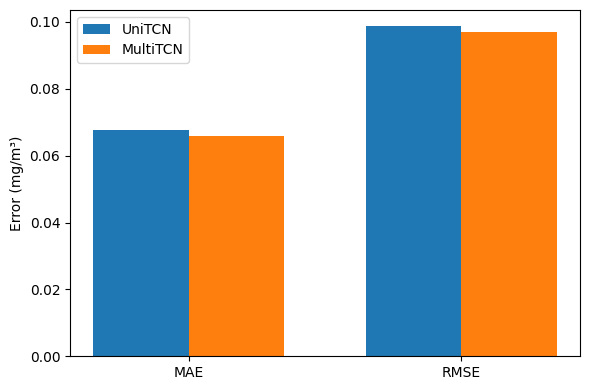

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["MAE", "RMSE"]

uni = [
    res_mashhad["MAE"],
    res_mashhad["RMSE"]
]

multi = [
    res_mashhad_multi["MAE"],
    res_mashhad_multi["RMSE"]
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x-width/2, uni, width, label="UniTCN")
plt.bar(x+width/2, multi, width, label="MultiTCN")

plt.xticks(x, metrics)
plt.ylabel("Error (mg/m³)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("Difference MAE =", abs(res_uni["MAE"]-res_multi["MAE"]))
print("Difference RMSE =", abs(res_uni["RMSE"]-res_multi["RMSE"]))
print("Difference SMAPE =", abs(res_uni["SMAPE"]-res_multi["SMAPE"]))

Difference MAE = 0.0016058035183498937
Difference RMSE = 0.0016441149811301792
Difference SMAPE = 0.12812595910409996


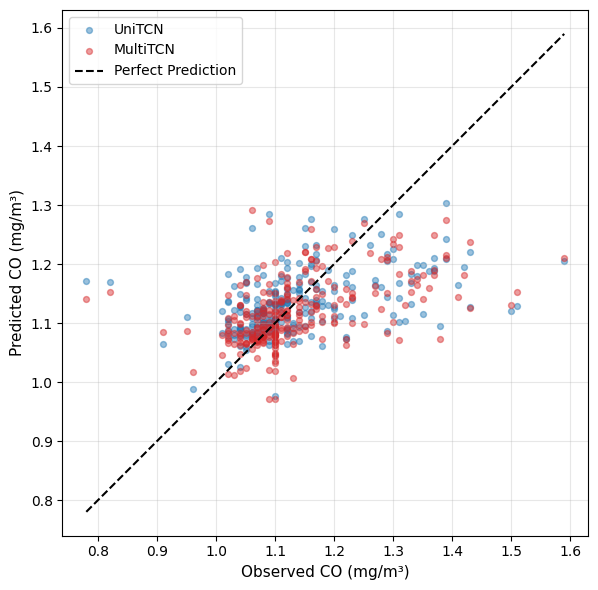

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#=========================
# UniTCN
#=========================
y_true_uni = np.asarray(res_uni["y_test"]).flatten()
y_pred_uni = np.asarray(res_uni["y_pred"]).flatten()

#=========================
# MultiTCN
#=========================
y_true_multi = np.asarray(res_multi["y_test"]).flatten()
y_pred_multi = np.asarray(res_multi["y_pred"]).flatten()


xmin = min(y_true_uni.min(), y_true_multi.min())
xmax = max(y_true_uni.max(), y_true_multi.max())

plt.figure(figsize=(6.5,6))

# UniTCN
plt.scatter(
    y_true_uni,
    y_pred_uni,
    s=18,
    alpha=0.45,
    color="#1f77b4",
    label="UniTCN"
)

# MultiTCN
plt.scatter(
    y_true_multi,
    y_pred_multi,
    s=18,
    alpha=0.45,
    color="#d62728",
    label="MultiTCN"
)

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    'k--',
    linewidth=1.5,
    label="Perfect Prediction"
)

plt.xlabel("Observed CO (mg/m³)", fontsize=11)
plt.ylabel("Predicted CO (mg/m³)", fontsize=11)


plt.grid(alpha=0.3)

plt.legend(frameon=True)

plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()

plt.show()

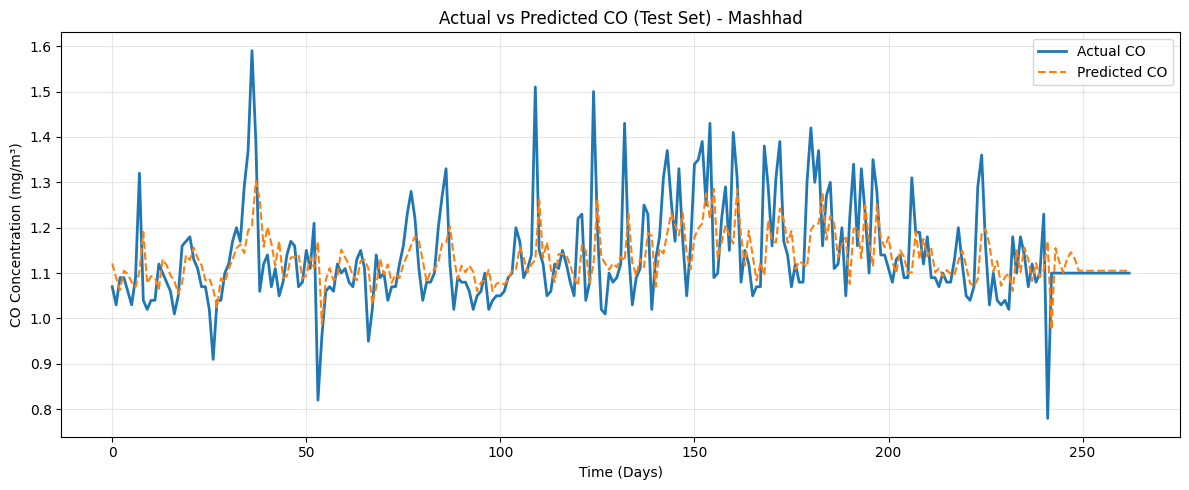

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_test = np.array(res_mashhad["y_test"]).ravel()
y_pred = np.array(res_mashhad["y_pred"]).ravel()

plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual CO", linewidth=2)
plt.plot(y_pred, label="Predicted CO", linestyle="--")
plt.xlabel("Time (Days)")
plt.ylabel("CO Concentration (mg/m³)")
plt.title("Actual vs Predicted CO (Test Set) - Mashhad")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("actual_vs_pred_mashhad.png", dpi=300, bbox_inches="tight")
plt.show()


**multiStep**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def recursive_multistep_forecast(results, steps=3):

    model = results["model"]
    X_test = results["X_test"]
    y_test = results["y_test_scaled"]
    scaler = results["scaler"]

    y_true_all = []
    y_pred_all = []

    for i in range(len(X_test)-steps):

        current_seq = X_test[i:i+1].copy()

        preds = []

        for _ in range(steps):

            pred = model.predict(current_seq, verbose=0)

            preds.append(pred[0,0])

            current_seq = np.concatenate(
                [current_seq[:,1:,:],
                 pred.reshape(1,1,1)],
                axis=1
            )

        y_pred_all.append(preds)
        y_true_all.append(y_test[i:i+steps])

    y_pred_all=np.array(y_pred_all)
    y_true_all=np.array(y_true_all)

    y_pred_inv=scaler.inverse_transform(y_pred_all)
    y_true_inv=scaler.inverse_transform(y_true_all)

    mae=mean_absolute_error(y_true_inv,y_pred_inv)
    rmse=np.sqrt(mean_squared_error(y_true_inv,y_pred_inv))

    smape=100*np.mean(
        2*np.abs(y_true_inv-y_pred_inv)/
        (np.abs(y_true_inv)+np.abs(y_pred_inv)+1e-8)
    )

    return {
        "MAE":mae,
        "RMSE":rmse,
        "SMAPE":smape,
        "y_true":y_true_inv,
        "y_pred":y_pred_inv
    }

In [ ]:
result_1 = {
    "MAE":res_mashhad["MAE"],
    "RMSE":res_mashhad["RMSE"],
    "SMAPE":res_mashhad["SMAPE"]
}

result_3 = recursive_multistep_forecast(
    res_mashhad,
    steps=3
)

result_7 = recursive_multistep_forecast(
    res_mashhad,
    steps=7
)

In [ ]:
comparison = pd.DataFrame({

    "Forecast Horizon":[
        "1-Day",
        "3-Day",
        "7-Day"
    ],

    "MAE":[
        result_1["MAE"],
        result_3["MAE"],
        result_7["MAE"]
    ],

    "RMSE":[
        result_1["RMSE"],
        result_3["RMSE"],
        result_7["RMSE"]
    ],

    "SMAPE (%)":[
        result_1["SMAPE"],
        result_3["SMAPE"],
        result_7["SMAPE"]
    ]

})

comparison=comparison.round(4)

print(comparison)

  Forecast Horizon     MAE    RMSE  SMAPE (%)
0            1-Day  0.0676  0.0986     5.8155
1            3-Day  0.0763  0.1061     6.5749
2            7-Day  0.0787  0.1091     6.7862


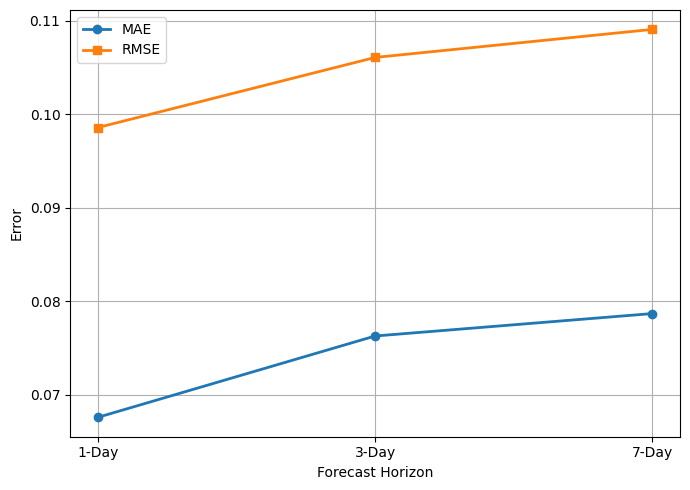

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(
    comparison["Forecast Horizon"],
    comparison["MAE"],
    marker='o',
    linewidth=2,
    label="MAE"
)

plt.plot(
    comparison["Forecast Horizon"],
    comparison["RMSE"],
    marker='s',
    linewidth=2,
    label="RMSE"
)

plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

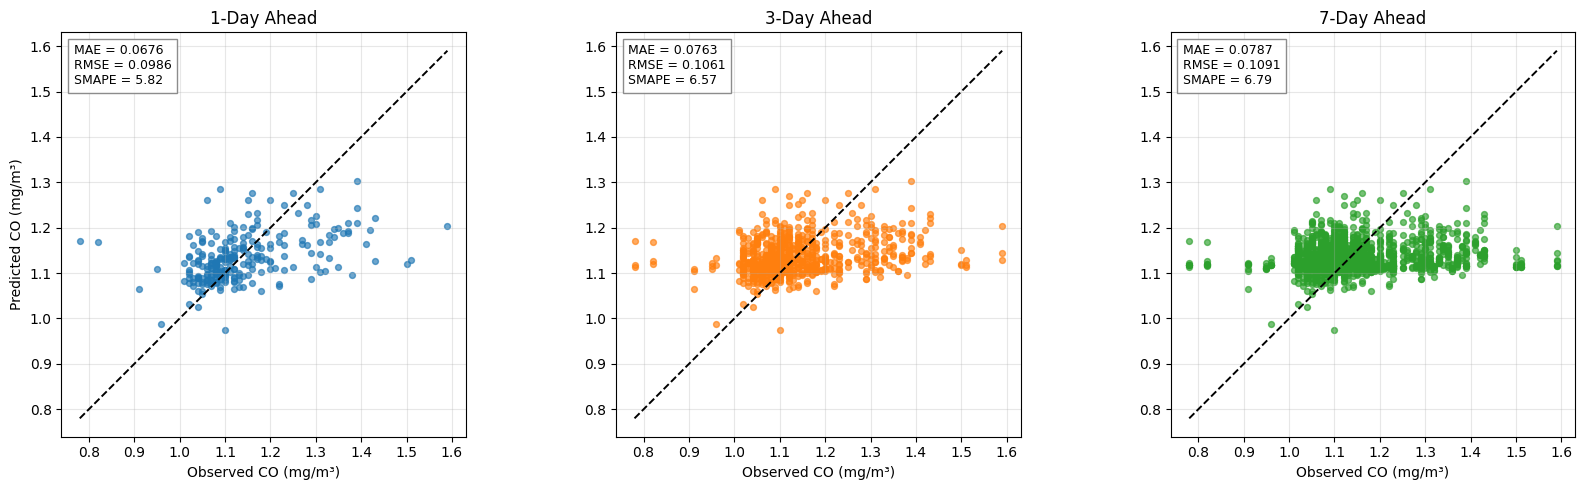

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

fig, axes = plt.subplots(1,3,figsize=(17,5))

datasets = [
    (
        res_mashhad["y_test"].flatten(),
        res_mashhad["y_pred"].flatten(),
        "1-Day Ahead",
        "tab:blue",
        res_mashhad["MAE"],
        res_mashhad["RMSE"],
        res_mashhad["SMAPE"]
    ),
    (
        result_3["y_true"].flatten(),
        result_3["y_pred"].flatten(),
        "3-Day Ahead",
        "tab:orange",
        result_3["MAE"],
        result_3["RMSE"],
        result_3["SMAPE"]
    ),
    (
        result_7["y_true"].flatten(),
        result_7["y_pred"].flatten(),
        "7-Day Ahead",
        "tab:green",
        result_7["MAE"],
        result_7["RMSE"],
        result_7["SMAPE"]
    )
]

for ax,(y_true,y_pred,title,color,mae,rmse,smape) in zip(axes,datasets):

    ax.scatter(
        y_true,
        y_pred,
        s=18,
        color=color,
        alpha=0.65
    )

    mn=min(y_true.min(),y_pred.min())
    mx=max(y_true.max(),y_pred.max())

    ax.plot([mn,mx],[mn,mx],
            'k--',
            lw=1.4,
            label="Perfect Prediction")

    r2=r2_score(y_true,y_pred)

    text = (
        f"MAE = {mae:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"SMAPE = {smape:.2f}"
    )

    ax.text(
        0.03,
        0.97,
        text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment='top',
        bbox=dict(facecolor='white',
                  edgecolor='gray',
                  alpha=0.9)
    )

    ax.set_title(title,fontsize=12)

    ax.set_xlabel("Observed CO (mg/m³)")

    if ax==axes[0]:
        ax.set_ylabel("Predicted CO (mg/m³)")

    ax.grid(alpha=0.3)

    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

plt.savefig(
    "Multistep_Scatter_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

y_test shape: (263,) | y_pred shape: (263,) | residuals shape: (263,)
Residual statistics -> mean: 0.005199824 std: 0.09850956 min: -0.39036936 max: 0.38542807


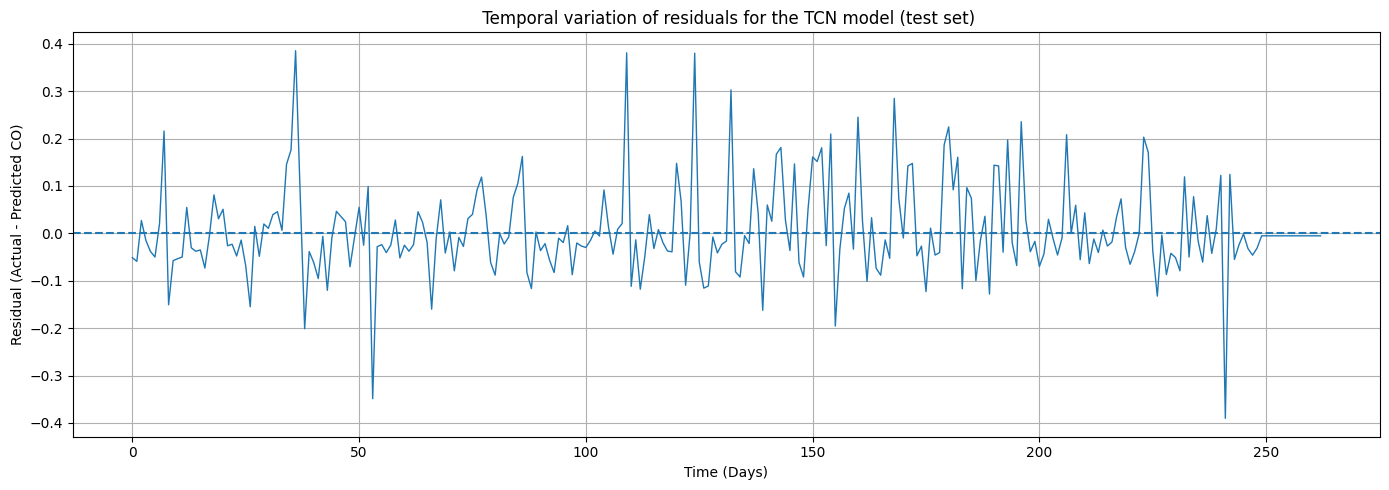

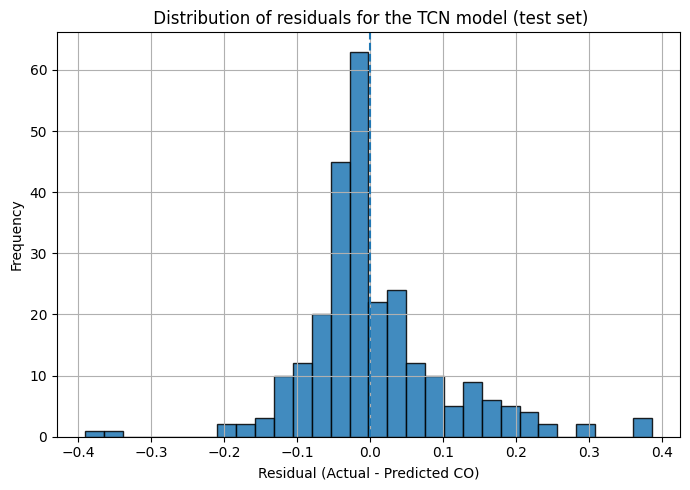

In [ ]:
# ===================== figure 7 , 8  =====================
import numpy as np
import matplotlib.pyplot as plt

if 'res_mashhad' not in globals():
    raise NameError("Variable 'res_mashhad' not found. Run run_tcn() first.")

if ('y_test' not in res_mashhad) or ('y_pred' not in res_mashhad):
    raise KeyError("'y_test' or 'y_pred' not found in res_mashhad output.")

y_test = np.asarray(res_mashhad['y_test']).reshape(-1)   # Actual values
y_pred = np.asarray(res_mashhad['y_pred']).reshape(-1)   # Predicted values

residuals = y_test - y_pred

print("y_test shape:", y_test.shape,
      "| y_pred shape:", y_pred.shape,
      "| residuals shape:", residuals.shape)
print("Residual statistics -> mean:", residuals.mean(),
      "std:", residuals.std(),
      "min:", residuals.min(),
      "max:", residuals.max())


plt.figure(figsize=(14,5))
plt.plot(residuals, linewidth=1)
plt.axhline(0, linestyle='--')

plt.xlabel("Time (Days)")
plt.ylabel("Residual (Actual - Predicted CO)")
plt.title(" Temporal variation of residuals for the TCN model (test set)")

plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.85)
plt.axvline(0, linestyle='--')

plt.xlabel("Residual (Actual - Predicted CO)")
plt.ylabel("Frequency")
plt.title(" Distribution of residuals for the TCN model (test set)")

plt.grid(True)
plt.tight_layout()
plt.show()


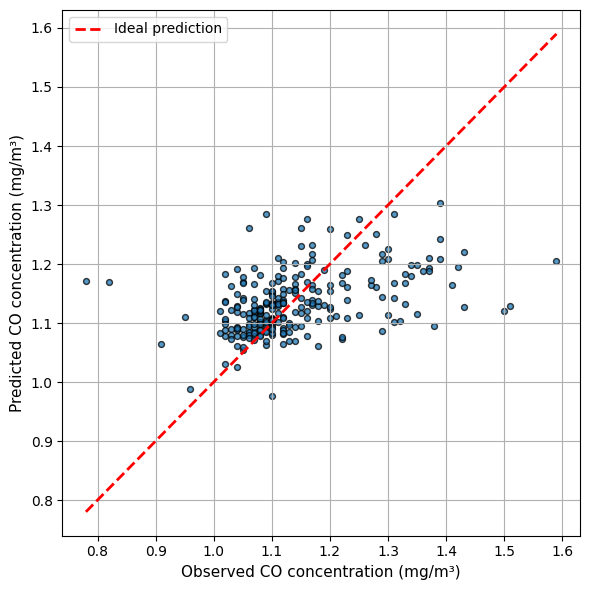

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_test = np.asarray(res_mashhad['y_test']).reshape(-1)
y_pred = np.asarray(res_mashhad['y_pred']).reshape(-1)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    s=18,
    alpha=0.75,
    edgecolors='black'
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='Ideal prediction'
)

plt.xlabel("Observed CO concentration (mg/m³)", fontsize=11)
plt.ylabel("Predicted CO concentration (mg/m³)", fontsize=11)

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

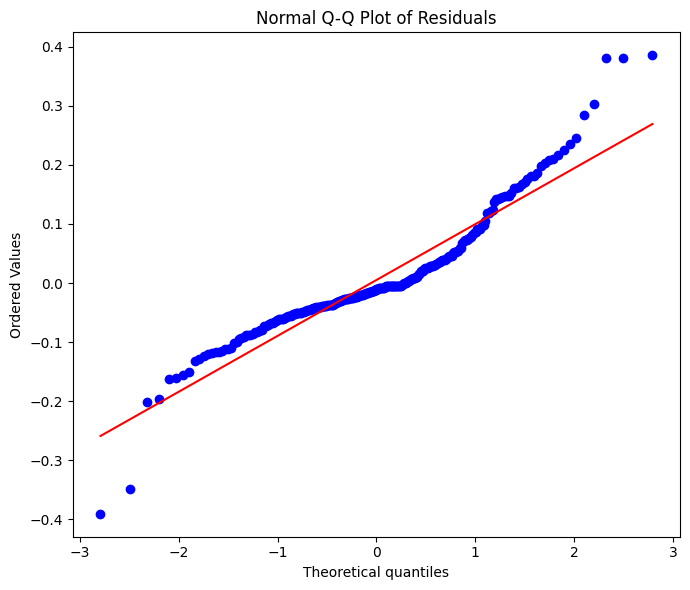

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("Normal Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

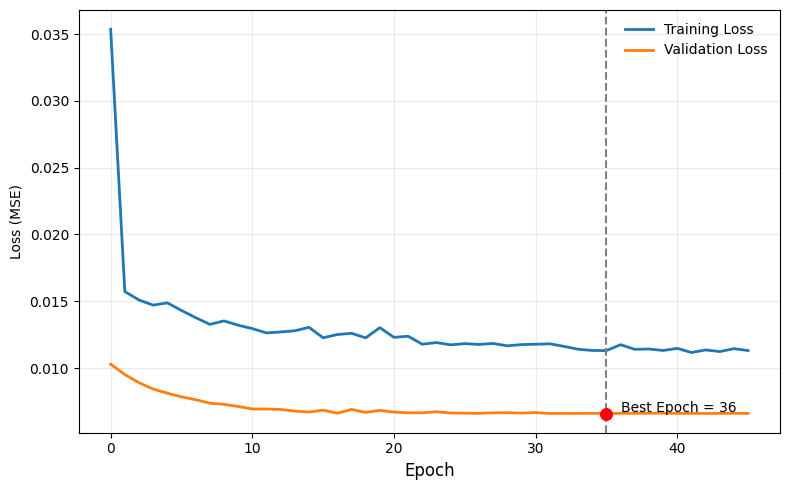

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

train_loss = history.history['loss']
val_loss   = history.history['val_loss']

best_epoch = np.argmin(val_loss) + 1

plt.figure(figsize=(8,5))

plt.plot(train_loss,
         linewidth=2,
         label='Training Loss')

plt.plot(val_loss,
         linewidth=2,
         label='Validation Loss')

plt.axvline(best_epoch-1,
            color='gray',
            linestyle='--',
            linewidth=1.5)

plt.scatter(best_epoch-1,
            val_loss[best_epoch-1],
            s=70,
            color='red',
            zorder=5)

plt.text(best_epoch,
         val_loss[best_epoch-1]*1.02,
         f'Best Epoch = {best_epoch}',
         fontsize=10)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss (MSE)")

plt.grid(alpha=0.25)

plt.legend(frameon=False)

plt.tight_layout()
plt.show()

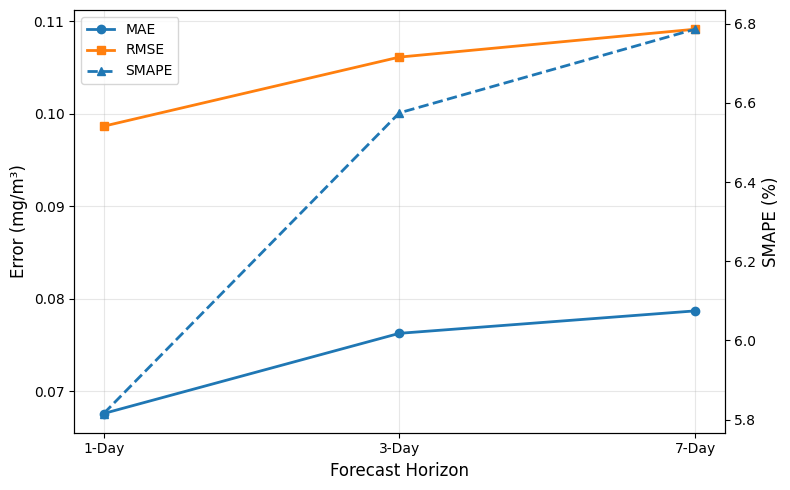

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# Forecast Horizons
# -----------------------------
horizons = ["1-Day", "3-Day", "7-Day"]

mae = [
    result_1["MAE"],
    result_3["MAE"],
    result_7["MAE"]
]

rmse = [
    result_1["RMSE"],
    result_3["RMSE"],
    result_7["RMSE"]
]

smape = [
    result_1["SMAPE"],
    result_3["SMAPE"],
    result_7["SMAPE"]
]


fig, ax1 = plt.subplots(figsize=(8,5))


ax1.plot(
    horizons,
    mae,
    marker='o',
    linewidth=2,
    label="MAE"
)

ax1.plot(
    horizons,
    rmse,
    marker='s',
    linewidth=2,
    label="RMSE"
)

ax1.set_xlabel("Forecast Horizon", fontsize=12)
ax1.set_ylabel("Error (mg/m³)", fontsize=12)

ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    horizons,
    smape,
    marker='^',
    linewidth=2,
    linestyle='--',
    label="SMAPE"
)

ax2.set_ylabel("SMAPE (%)", fontsize=12)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "Forecast_Horizon_Performance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

model 6

# **Hybrid Prophet–LSTM**

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - loss: 0.0651 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0211 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0207 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0205 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0202 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0202 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0202 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0201 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0199 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 10/50
59/59 ━━━━

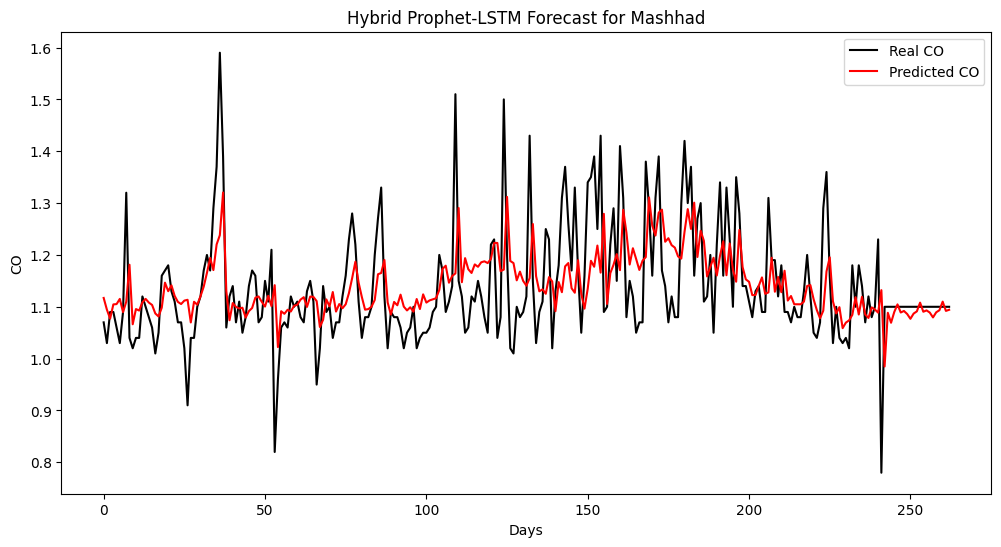

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0257 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0117 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0113 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0111 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0105 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0096 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0087 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0078 - val_loss: 0.0032 - learning_rate: 0.0010
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0072 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 10/50
99/99 ━━━━━━

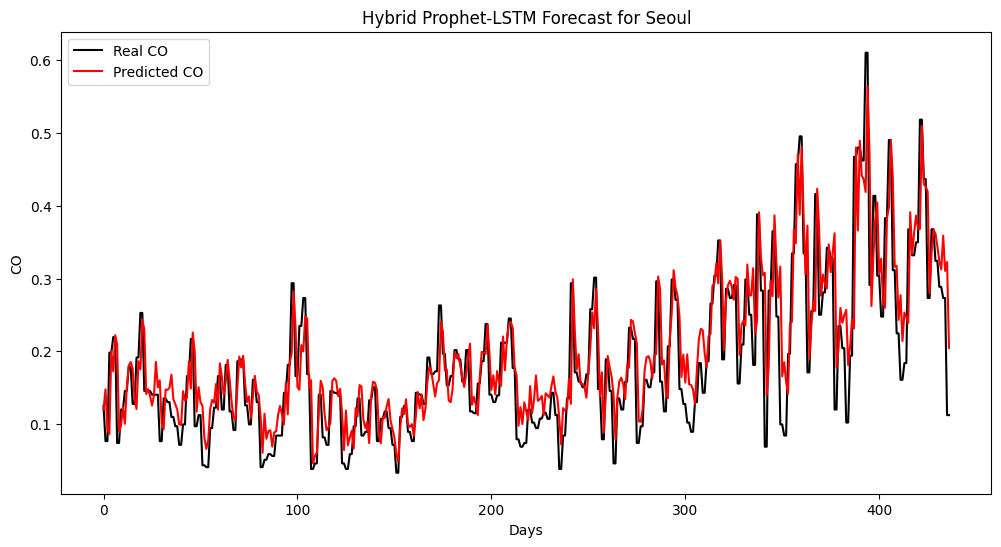


=========== FINAL Hybrid Prophet-LSTM COMPARISON ===========
      City       MAE      RMSE      SMAPE   Accuracy  \
0  Mashhad  0.069878  0.097570   6.017525  93.982475   
1    Seoul  0.038770  0.056353  23.572954  76.427046   

                                              y_test  \
0  [[1.07], [1.03], [1.09], [1.09], [1.06], [1.03...   
1  [[0.125097125], [0.076590077], [0.076590077], ...   

                                              y_pred  \
0  [[1.1170822491884942], [1.0944274536029996], [...   
1  [[0.12036541430987452], [0.14761584234098768],...   

                                             summary  
0  Hybrid Prophet-LSTM Mashhad -> MAE: 0.0699, RM...  
1  Hybrid Prophet-LSTM Seoul -> MAE: 0.0388, RMSE...  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from prophet import Prophet

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def hybrid_prophet_lstm(file_path, city_name, seq_len=7, epochs=50, batch_size=16):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    if 'CO' not in df.columns:
        raise SystemExit(f"ستون 'CO' پیدا نشد در {city_name}")
    data = df[['Date','CO']].rename(columns={'Date':'ds','CO':'y'})

    prophet_train_idx = int(len(data)*0.8)
    train_prophet = data.iloc[:prophet_train_idx]
    test_prophet = data.iloc[prophet_train_idx:]

    model_prophet = Prophet(daily_seasonality=True, yearly_seasonality=True)
    model_prophet.fit(train_prophet)

    future = pd.DataFrame({"ds": data['ds']})
    forecast = model_prophet.predict(future)
    residuals = data['y'].values - forecast['yhat'].values
    residuals = residuals.reshape(-1,1)
    scaler = MinMaxScaler()
    scaler.fit(residuals[:prophet_train_idx])
    residuals_scaled = scaler.transform(residuals)
    def create_sequences(values, time_steps=seq_len):
        X, y = [], []
        for i in range(len(values) - time_steps):
            X.append(values[i:i+time_steps])
            y.append(values[i+time_steps])
        return np.array(X), np.array(y)

    X, y = create_sequences(residuals_scaled, seq_len)
    split = int(len(X)*0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    tf.keras.backend.clear_session()
    model = Sequential([
        Input(shape=(seq_len,1)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')

    checkpoint_path = f"best_hybrid_{city_name}.weights.h5"
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, save_weights_only=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
    ]

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        shuffle=False,
        callbacks=callbacks,
        verbose=1
    )
    model.load_weights(checkpoint_path)

    y_pred_scaled = model.predict(X_test)
    y_pred_residual = scaler.inverse_transform(y_pred_scaled)
    y_test_total = data['y'].values[len(data)-len(y_test):]
    y_pred_total = forecast['yhat'].values[-len(y_test):] + y_pred_residual.ravel()

    mae = mean_absolute_error(y_test_total, y_pred_total)
    rmse = np.sqrt(mean_squared_error(y_test_total, y_pred_total))
    smape_val = 100*np.mean(2*np.abs(y_pred_total - y_test_total)/(np.abs(y_test_total)+np.abs(y_pred_total)+1e-8))
    accuracy = 100 - smape_val

    print(f"\n📊 Hybrid Prophet-LSTM - {city_name}")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%, Accuracy: {accuracy:.2f}%")

    plt.figure(figsize=(12,6))
    plt.plot(y_test_total, label='Real CO', color='black')
    plt.plot(y_pred_total, label='Predicted CO', color='red')
    plt.title(f"Hybrid Prophet-LSTM Forecast for {city_name}")
    plt.xlabel("Days")
    plt.ylabel("CO")
    plt.legend()
    plt.show()
    return {
      "City": city_name,
      "MAE": mae,
      "RMSE": rmse,
      "SMAPE": smape_val,
      "Accuracy": accuracy,
      "y_test": y_test_total.reshape(-1, 1),
      "y_pred": y_pred_total.reshape(-1, 1),
      "summary": f"Hybrid Prophet-LSTM {city_name} -> MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%, Accuracy: {accuracy:.2f}%"
    }


res_mashhad = hybrid_prophet_lstm("Mashhad_CO_Median.csv", "Mashhad")
res_seoul = hybrid_prophet_lstm("Seoul_Hybrid_Daily_Clean.csv", "Seoul")

results_df = pd.DataFrame([res_mashhad, res_seoul])
print("\n=========== FINAL Hybrid Prophet-LSTM COMPARISON ===========")
print(results_df)




#  Performance of models across low, medium, and high CO levels


=========== Running Linear Regression for Mashhad ===========
MAE: 0.0675
RMSE: 0.0981
SMAPE: 5.81%
Accuracy: 94.19%

=========== Running Linear Regression for Seoul ===========
MAE: 0.0350
RMSE: 0.0540
SMAPE: 21.00%
Accuracy: 79.00%

=========== Running Prophet for Mashhad ===========
MAE: 0.0794
RMSE: 0.1065
SMAPE: 6.84%
Accuracy: 93.16%


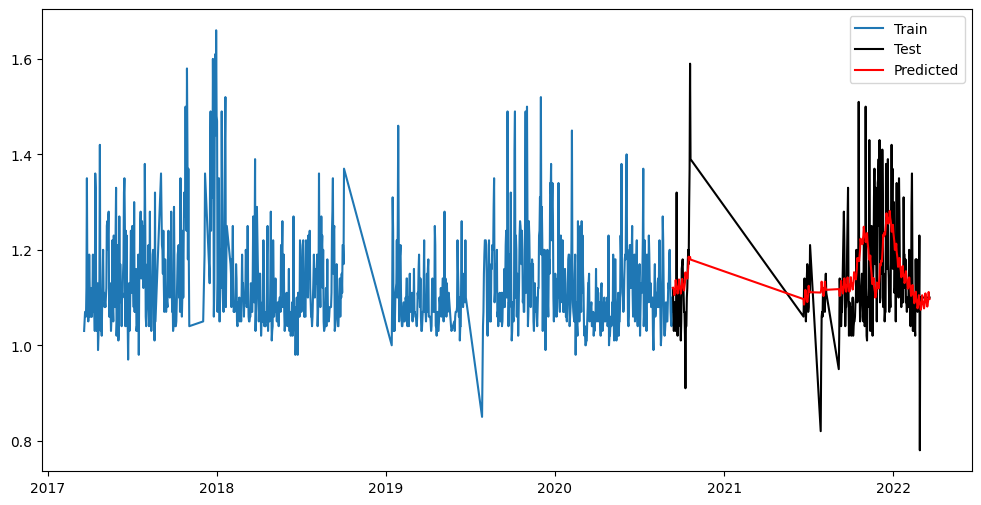


=========== Running Prophet for Seoul ===========
MAE: 0.0674
RMSE: 0.0864
SMAPE: 38.02%
Accuracy: 61.98%


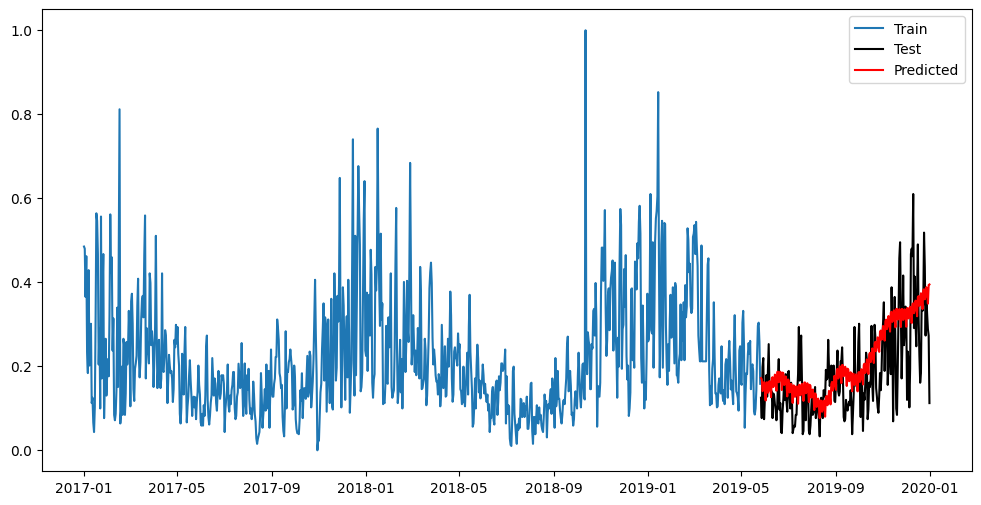

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0435 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0175 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0174 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0173 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0172 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0170 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0169 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0164 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 9/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0165
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00050000

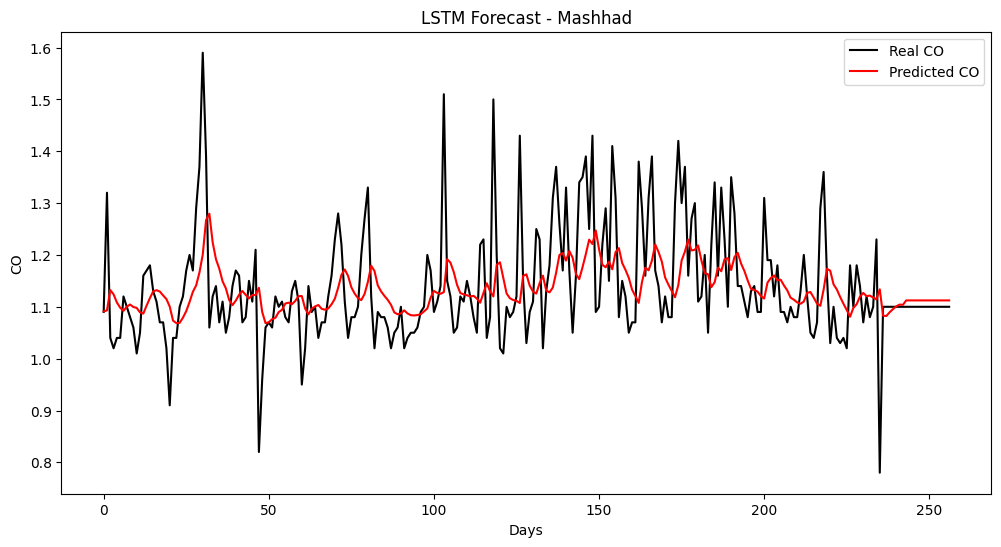

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0302 - val_loss: 0.0220 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0172 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0167 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0156 - val_loss: 0.0133 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0147 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0137 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0124 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0111 - val_loss: 0.0078 - learning_rate: 0.0010
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0100 - val_loss: 0.0069 - learning_rate: 0.0010
Epoch 10/50
99/99 ━━━

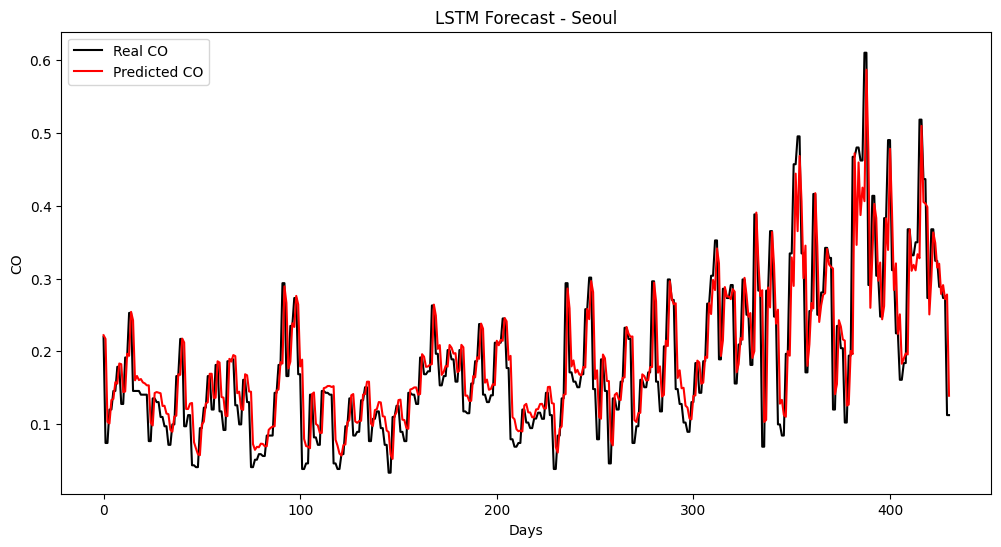


=========== Bi-LSTM for Mashhad ===========
Shapes -> X_train: (1048, 7, 1) X_test: (264, 7, 1)
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0379
Epoch 1: val_loss improved from inf to 0.00931, saving model to best_bilstm_Mashhad.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - loss: 0.0377 - val_loss: 0.0093 - learning_rate: 0.0010
Epoch 2/50
56/59 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0163
Epoch 2: val_loss did not improve from 0.00931
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0162 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 3/50
58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0166
Epoch 3: val_loss did not improve from 0.00931
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0165 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0164
Epoch 4: val_loss improved from 0.00931 to 0.00905, saving model to best_bilstm_Mashhad.weights.h5
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0164 - 

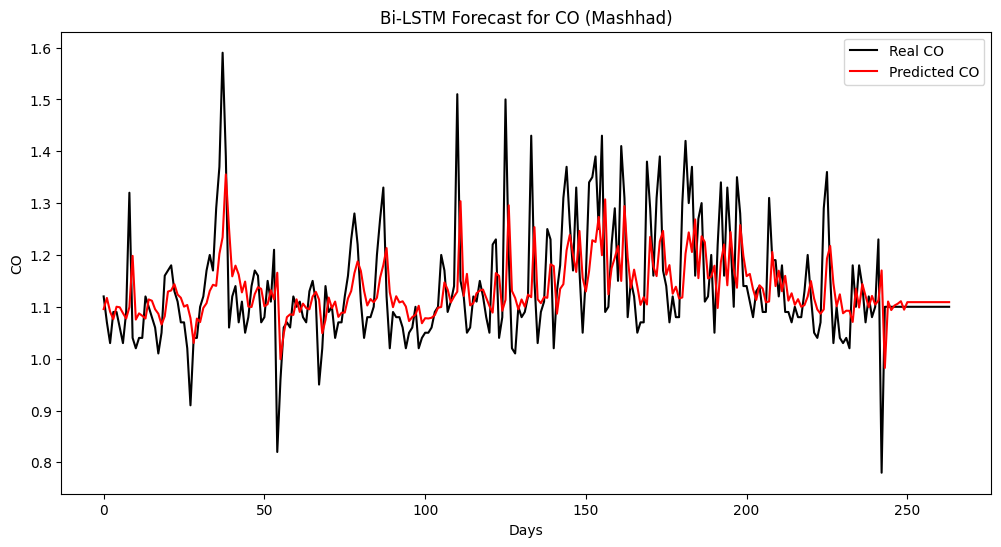


=========== Bi-LSTM for Seoul ===========
Shapes -> X_train: (1745, 7, 1) X_test: (438, 7, 1)
Epoch 1/50
97/99 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0241
Epoch 1: val_loss improved from inf to 0.01739, saving model to best_bilstm_Seoul.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0239 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 2/50
98/99 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0144
Epoch 2: val_loss improved from 0.01739 to 0.01724, saving model to best_bilstm_Seoul.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0144 - val_loss: 0.0172 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0135
Epoch 3: val_loss improved from 0.01724 to 0.01403, saving model to best_bilstm_Seoul.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0135 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 4/50
96/99 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0122
Epoch 4: val_loss improved from 0.01403 to 0.01338, saving m

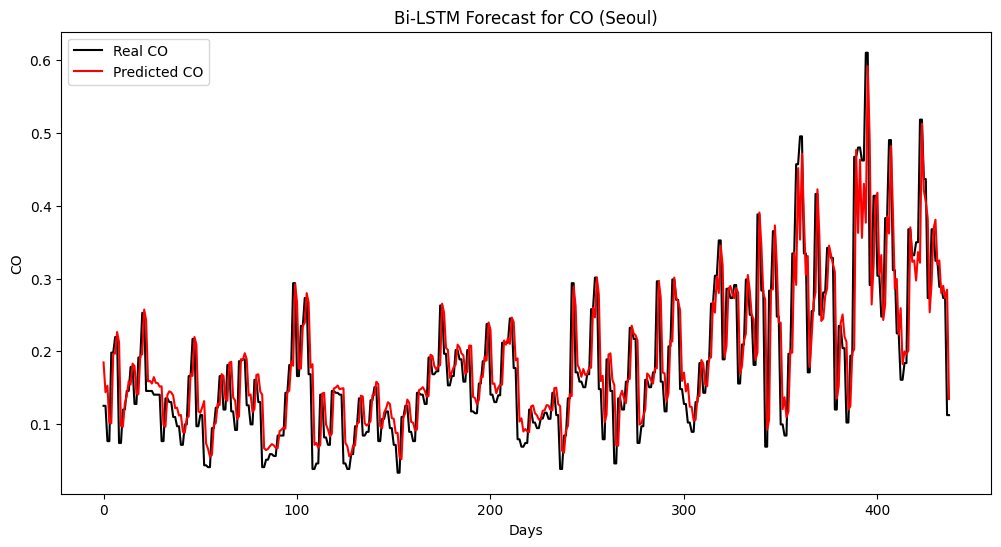

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0761 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0210 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0210 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0206 - val_loss: 0.0139 - learning_rate: 0.0010
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0204 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0202 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0198 - val_loss: 0.0131 - learning_rate: 5.0000e-04
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0198 - val_loss: 0.0131 - learning_rate: 5.0000e-04
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0197 - val_loss: 0.0

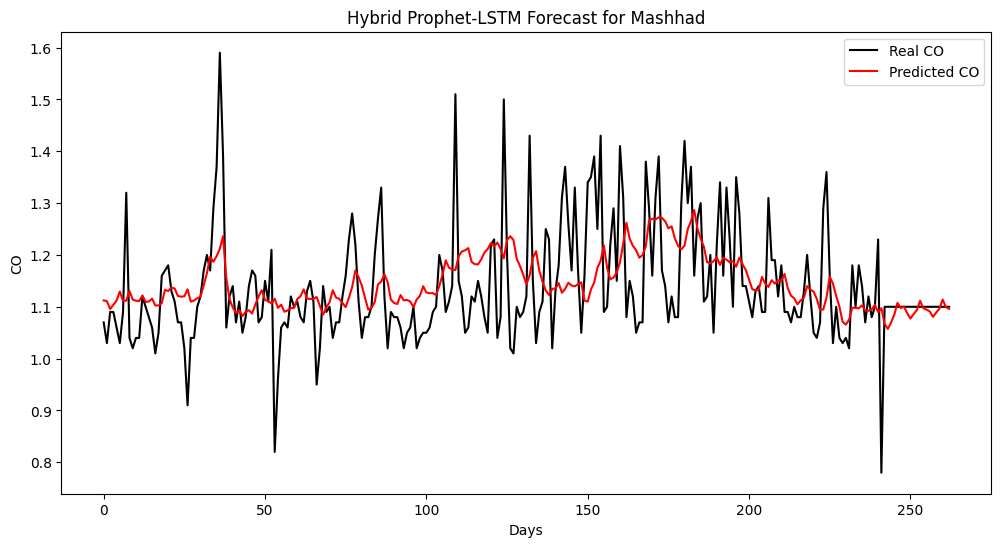

Epoch 1/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0182 - val_loss: 0.0063 - learning_rate: 0.0010
Epoch 2/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0112 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 3/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0108 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 4/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0101 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 5/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0094 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 6/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0086 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 7/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0078 - val_loss: 0.0033 - learning_rate: 0.0010
Epoch 8/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0074 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 9/50
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0071 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 10/50
99/99 ━

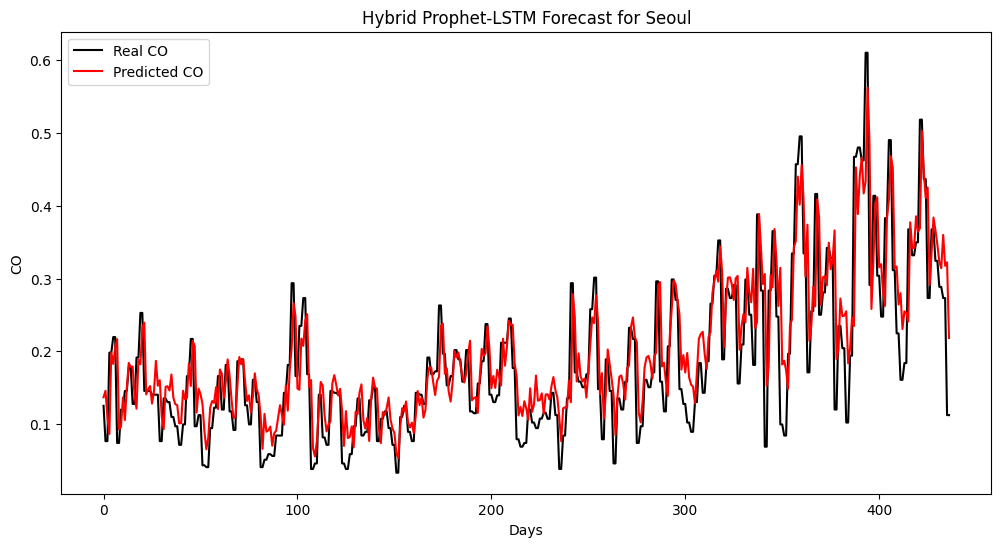


==== Mashhad - Linear Regression ====
  Pollution Level       MAE  SMAPE (%)  Accuracy (%)
0             Low  0.067512   6.307149     93.692851
1          Medium  0.027839   2.483692     97.516308
2            High  0.101443   8.212118     91.787882

==== Seoul - Linear Regression ====
  Pollution Level       MAE  SMAPE (%)  Accuracy (%)
0             Low  0.034928  32.900589     67.099411
1          Medium  0.024772  14.728185     85.271815
2            High  0.044749  15.824545     84.175455

==== Mashhad - Prophet ====
  Pollution Level       MAE  SMAPE (%)  Accuracy (%)
0             Low  0.098337   9.015667     90.984333
1          Medium  0.033591   2.952259     97.047741
2            High  0.101559   8.220676     91.779324

==== Seoul - Prophet ====
  Pollution Level       MAE  SMAPE (%)  Accuracy (%)
0             Low  0.087243  65.401056     34.598944
1          Medium  0.044225  24.098315     75.901685
2            High  0.070816  25.619832     74.380168

==== Mashhad - LSTM

In [ ]:

res_mashhad_lin = run_linear_no_leak("Mashhad_CO_Median.csv", "Mashhad", col_name="CO")
res_seoul_lin  = run_linear_no_leak("Seoul_Hybrid_Daily_Clean.csv", "Seoul", col_name="CO")

res_mashhad_prophet = run_prophet("Mashhad_CO_Median.csv", "Mashhad")
res_seoul_prophet  = run_prophet("Seoul_Hybrid_Daily_Clean.csv", "Seoul")

res_mashhad_lstm = run_lstm("Mashhad_CO_Median.csv", "Mashhad")
res_seoul_lstm  = run_lstm("Seoul_Hybrid_Daily_Clean.csv", "Seoul")

res_mashhad_bilstm = run_bilstm("Mashhad_CO_Median.csv", "Mashhad")
res_seoul_bilstm  = run_bilstm("Seoul_Hybrid_Daily_Clean.csv", "Seoul")

res_mashhad_tcn = run_tcn("Mashhad_CO_Median.csv", "Mashhad")
res_seoul_tcn  = run_tcn("Seoul_Hybrid_Daily_Clean.csv", "Seoul")

res_mashhad_hybrid = hybrid_prophet_lstm("Mashhad_CO_Median.csv", "Mashhad")
res_seoul_hybrid  = hybrid_prophet_lstm("Seoul_Hybrid_Daily_Clean.csv", "Seoul")


models = [

    ("Linear Regression", {"Mashhad": res_mashhad_lin, "Seoul": res_seoul_lin}),
    ("Prophet", {"Mashhad": res_mashhad_prophet, "Seoul": res_seoul_prophet}),
    ("LSTM", {"Mashhad": res_mashhad_lstm, "Seoul": res_seoul_lstm}),
    ("Bi-LSTM", {"Mashhad": res_mashhad_bilstm, "Seoul": res_seoul_bilstm}),
    ("TCN", {"Mashhad": res_mashhad_tcn, "Seoul": res_seoul_tcn}),
    ("Hybrid Prophet-LSTM", {"Mashhad": res_mashhad_hybrid, "Seoul": res_seoul_hybrid}),
]

for model_name, cities_dict in models:
    for city, res_dict in cities_dict.items():
        evaluate_levels_from_dict(res_dict, city, model_name)

In [ ]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df = pd.read_csv("Mashhad_CO_Median.csv")

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
data = df[["Date", "CO"]].rename(columns={"Date": "ds", "CO": "y"})
data = data.groupby("ds").mean().reset_index()
data = data.dropna().reset_index(drop=True)

split = int(len(data) * 0.8)
train = data.iloc[:split]
test  = data.iloc[split:].reset_index(drop=True)

model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

future = test[["ds"]]
forecast = model.predict(future)

y_test_values = test["y"].values
y_pred_values = forecast["yhat"].values


In [ ]:
import numpy as np
results = []

horizons = {
    "5 Days": (5, 1),
    "15 Days": (15, 2),
    "1 Month": (30, 5),
    "6 Months": (180, 10),
    "1 Year": (365, 15)
}

mean_y = np.mean(y_test_values)

for name, (day, window) in horizons.items():
    if day + window >= len(y_test_values):
        continue

    start = max(0, day - window - 1)
    end   = min(len(y_test_values), day + window)

    y_true_h = y_test_values[start:end]
    y_pred_h = y_pred_values[start:end]

    mae = mean_absolute_error(y_true_h, y_pred_h)
    rmse = np.sqrt(mean_squared_error(y_true_h, y_pred_h))

    accuracy = 100 * (1 - mae / mean_y)

    results.append({
        "Time": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "Accuracy (%)": round(accuracy, 2)
    })


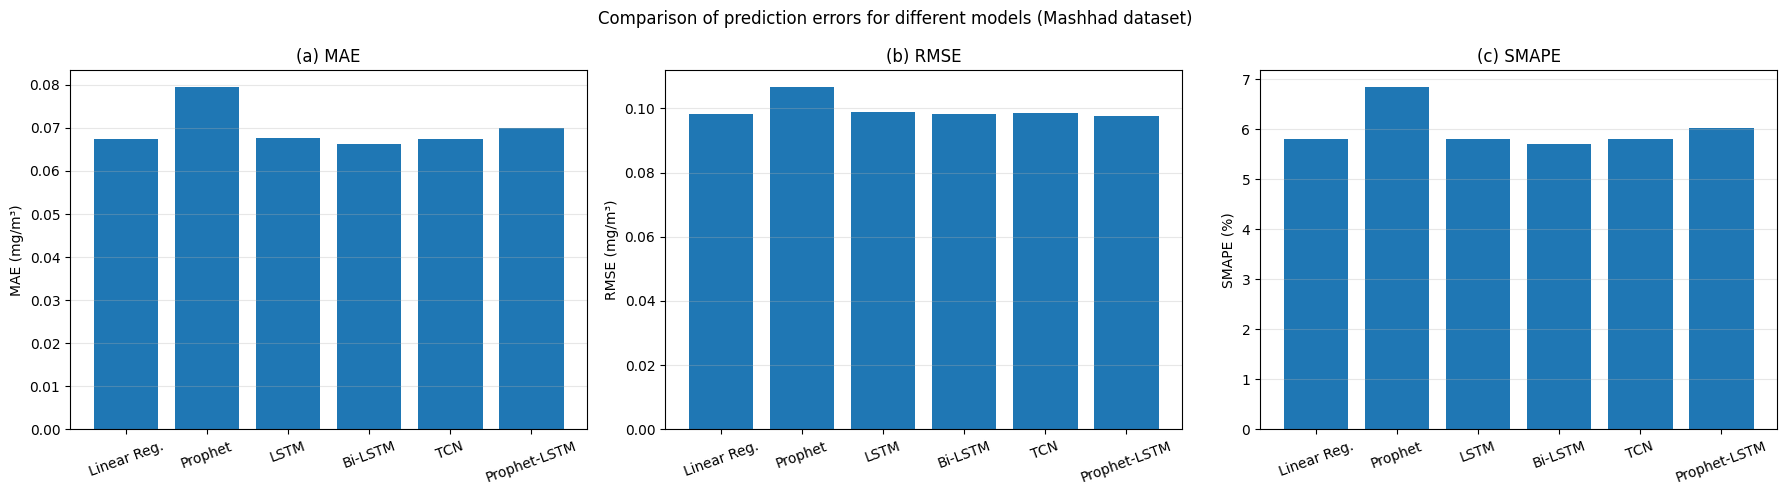

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

models = ["Linear Reg.", "Prophet", "LSTM", "Bi-LSTM", "TCN", "Prophet-LSTM"]
mae = [0.0675, 0.0794, 0.0676, 0.0663, 0.0675, 0.0699]
rmse = [0.0981, 0.1065, 0.0990, 0.0981, 0.0986, 0.0976]
smape = [5.81, 6.84, 5.81, 5.70, 5.81, 6.02]

axes[0].bar(models, mae)
axes[0].set_title("(a) MAE")
axes[0].set_ylabel("MAE (mg/m³)")
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(models, rmse)
axes[1].set_title("(b) RMSE")
axes[1].set_ylabel("RMSE (mg/m³)")
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(models, smape)
axes[2].set_title("(c) SMAPE")
axes[2].set_ylabel("SMAPE (%)")
axes[2].tick_params(axis='x', rotation=20)

for ax in axes:
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Comparison of prediction errors for different models (Mashhad dataset)")
plt.tight_layout()
plt.savefig("model_comparison_separate.png", dpi=300)
plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Residuals
residuals = y_test_inv.flatten() - y_pred_inv.flatten()

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=30, edgecolor='black')

plt.xlabel("Residual (Actual − Predicted)")
plt.ylabel("Frequency")
plt.title("Histogram of Prediction Residuals")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Figure6_Residual_Histogram.png", dpi=600)
plt.show()